In [1]:
from fears.utils import AutoRate
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
from sklearn.linear_model import LinearRegression
import pandas as pd
import pickle

In [2]:
cfu_file = '../calibration_data/calibration_05272026/CFU_counts_Paer_05262026.xlsx'

df = pd.read_excel(cfu_file)

df['Dilution 10^5 (R1)'] = df['Dilution 10^5 (R1)']*10**5/100
df['Dilution 10^5 (R2)'] = df['Dilution 10^5 (R2)']*10**5/100
df['Dilution 10^5 (R3)'] = df['Dilution 10^5 (R3)']*10**5/100

df['mean'] = df[['Dilution 10^5 (R1)', 'Dilution 10^5 (R2)', 'Dilution 10^5 (R3)']].mean(axis=1)
df['err'] = df[['Dilution 10^5 (R1)','Dilution 10^5 (R2)', 'Dilution 10^5 (R3)']].std(axis=1)/np.sqrt(3)

df['dilution'] = 2**(df['col']-1)

df.dropna(inplace=True)

df

,col,Dilution 10^5 (R1),Dilution 10^5 (R2),Dilution 10^5 (R3),mean,err,dilution
0,2,114000.0,123000.0,77000.0,104666.666667,14075.194887,2
1,4,34000.0,33000.0,25000.0,30666.666667,2848.001248,8
2,6,13000.0,13000.0,10000.0,12000.000000,1000.000000,32


In [3]:
od_file = '../calibration_data/calibration_05272026/Paer_OD_20260526.xlsx'

p_od = AutoRate.Plate(od_file,mode='single_measurement')
od_data = p_od.od_data_to_dict(p_od.data)

# col 11 is background

rows = ['B','C','D','E','F','G']
cols = ['2','3','4','5','6','7','8','9','10','11']

bg_est = np.mean([od_data[r+'11'] for r in rows])

od_mean = []
od_err = []

for col in cols:
    od_mean.append(np.mean([od_data[r+col] for r in rows]))
    od_err.append(np.std([od_data[r+col] for r in rows])/np.sqrt(len(rows)))

od_mean = od_mean - bg_est

od_mean = np.array(od_mean)
od_err = np.array(od_err)

<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
C:\Users\s3ayy\AppData\Local\Temp\ipykernel_31604\531502997.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('CFU/$\mathrm{\mu}$L',fontsize=12)


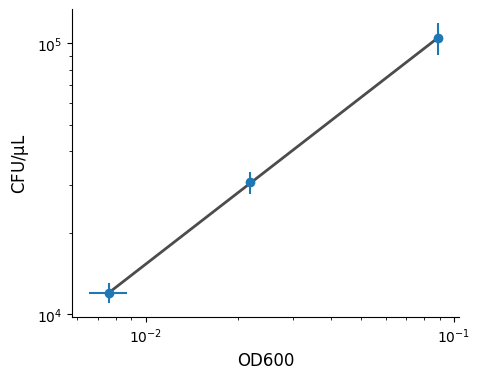

In [4]:
fig,ax = plt.subplots(figsize=(5,4))

sample_cols = df['col'].values

ax.errorbar(od_mean[sample_cols-2],df['mean'],yerr=df['err'],xerr=od_err[sample_cols-2],fmt='o',label='CFU')

ax.set_yscale('log')
ax.set_xscale('log')

# weighted linear regression

x = np.log10(od_mean[sample_cols-2])
y = np.log10(df['mean'])
yerr = np.log10(df['err'])

reg = LinearRegression().fit(x.reshape(-1,1),y,sample_weight=1/yerr)

# plot fit

x_fit = np.linspace(np.min(x),np.max(x),100)
y_fit = reg.predict(x_fit.reshape(-1,1))

ax.plot(10**x_fit,10**y_fit,'k',label='fit',alpha=0.7,linewidth=2)

ax.set_xlabel('OD600',fontsize=12)

ax.set_ylabel('CFU/$\mathrm{\mu}$L',fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


In [5]:
print('coef: ' + str(reg.coef_[0]))
print('intercept: ' + str(reg.intercept_))

coef: 0.8818187212593991
intercept: 5.948300940214935


In [6]:
ab_file = '../calibration_data/calibration_05272026/Paer_AB_20260526.xlsx'

p_ab = AutoRate.Plate(ab_file,mode='single_measurement')
ab_data = p_ab.od_data_to_dict(p_ab.data)

ab_background = np.mean([ab_data[r+'11'] for r in rows])

rows = ['C','D','E','F','G']

ab_mean = []
ab_err = []

for col in cols:
    ab_mean.append(np.mean([ab_data[r+col] for r in rows]))
    ab_err.append(np.std([ab_data[r+col] for r in rows])/np.sqrt(len(rows)))

ab_mean = np.array(ab_mean) - ab_background

ab_mean = np.array(ab_mean)
ab_err = np.array(ab_err)

In [7]:
ab_background

np.float64(278.1666666666667)

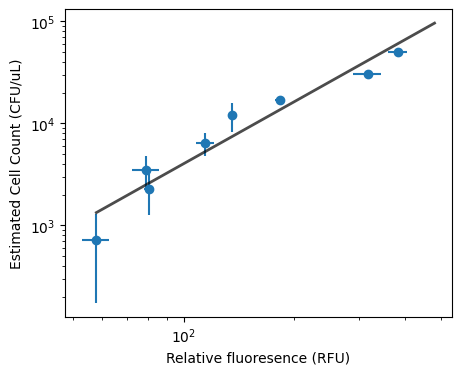

In [8]:
# convert OD estimates to CFU

od_t = np.log10(od_mean[0:-1])
cell_count_est = 10**reg.predict(od_t.reshape(-1,1))
cell_count_est_err = cell_count_est*np.log(10)*od_err[0:-1]/od_mean[0:-1]

fig,ax = plt.subplots(figsize=(5,4))

ax.errorbar(ab_mean[1:-1],cell_count_est[1:],yerr=cell_count_est_err[1:],xerr=ab_err[1:-1],fmt='o',label='AB')

ax.set_yscale('log')
ax.set_xscale('log')

# weighted linear regression

x = np.log10(ab_mean[1:-1])
y = np.log10(cell_count_est[1:])
w = 1/cell_count_est_err[1:]

reg = LinearRegression().fit(x.reshape(-1,1),y)

# plot fit

x_fit = np.linspace(np.min(x),np.max(x)+0.1,100)
y_fit = reg.predict(x_fit.reshape(-1,1))

ax.plot(10**x_fit,10**y_fit,'k',label='fit',alpha=0.7,linewidth=2)

ax.set_xlabel("Relative fluoresence (RFU)")
ax.set_ylabel("Estimated Cell Count (CFU/uL)")

plt.show()

In [16]:
# pickle the fit

with open('calibration_Paer_05202026.pkl','wb') as f:
    pickle.dump(reg,f)